In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

from IPython.display import clear_output
import matplotlib.pyplot as plt


In [10]:
# ── 1. Policy Network ──────────────────────────────────────────
# Input: 4 state values → Output: probabilities for 2 actions
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
            nn.Softmax(dim=-1)   # outputs probabilities that sum to 1
        )

    def forward(self, x):
        return self.net(x)

# ── 2. Run one episode, collect (log_prob, reward) pairs ──────
def run_episode(env, policy):
    state, _ = env.reset()
    log_probs, rewards = [], []

    for _ in range(500):  # max steps
        state_t = torch.FloatTensor(state)
        probs = policy(state_t)

        # Sample an action from the probability distribution
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        log_probs.append(dist.log_prob(action))   # log π(a|s)

        state, reward, done, truncated, _ = env.step(action.item())
        rewards.append(reward)

        if done or truncated:
            break

    return log_probs, rewards

# ── 3. Compute discounted returns ─────────────────────────────
def compute_returns(rewards, gamma=0.99):
    returns, G = [], 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns)
    # Normalize for stable training
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns

# ── 4. Training loop ──────────────────────────────────────────
env = gym.make("CartPole-v1")
policy = Policy()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

for episode in range(301):
    log_probs, rewards = run_episode(env, policy)
    returns = compute_returns(rewards)

    # REINFORCE loss: push up log_prob of actions that got high return
    loss = -torch.stack(log_probs) * returns   # shape: [T]
    loss = loss.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if episode % 50 == 0:
        print(f"Episode {episode:4d} | Steps survived: {len(rewards):3d}")

env.close()

Episode    0 | Steps survived:  24
Episode   50 | Steps survived:  18
Episode  100 | Steps survived:  18
Episode  150 | Steps survived:  75
Episode  200 | Steps survived: 194
Episode  250 | Steps survived: 129
Episode  300 | Steps survived: 119


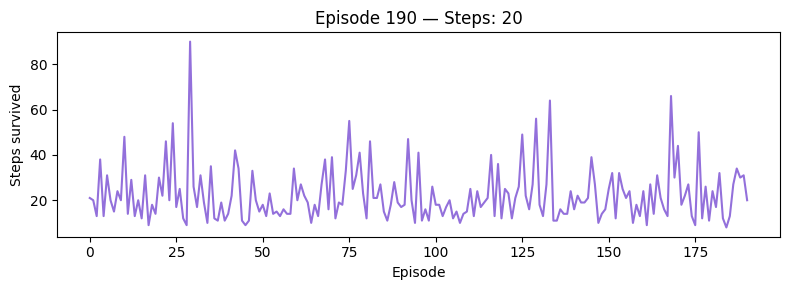

In [11]:

rewards = []

for episode in range(200):
    state, _ = env.reset()
    total = 0

    for _ in range(301):
        action = env.action_space.sample()  # swap with your policy
        state, reward, done, truncated, _ = env.step(action)
        total += reward
        if done or truncated:
            break

    rewards.append(total)

    # Redraw every 10 episodes
    if episode % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8, 3))
        plt.plot(rewards, color='mediumpurple')
        plt.title(f'Episode {episode} — Steps: {total:.0f}')
        plt.xlabel('Episode')
        plt.ylabel('Steps survived')
        plt.tight_layout()
        plt.show()